---------------------------------------------------------------------------------------------------------------
# Return Risk Analysis
---------------------------------------------------------------------------------------------------------------
## Content Log:
1. Import Libraries
2. Load Data
3. Calculate Daily Return
4. Return Analysis
5. Risk Analysis
6. Risk vs Return Plot
7. Key Observations
---------------------------------------------------------------------------------------------------------------

# 01. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 02. Load Data

In [2]:
data_path = "../../data/raw_data"

datasets = {}

for file in os.listdir(data_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_path, file), low_memory=False)
        df["Ticker"] = file.replace(".csv", "")
        datasets[file] = df

# 03. Calculate Daily Return

In [3]:
for df in datasets.values():
    if "Close" in df.columns:
        df["Returns"] = df["Close"].pct_change()

# 04. Return Analysis

In [4]:
returns_summary = {}

for name, df in datasets.items():
    if "Returns" in df.columns:
        mean_return = df["Returns"].mean()
        returns_summary[name] = mean_return

returns_df = pd.DataFrame.from_dict(returns_summary, orient="index", columns=["Mean Return"])
returns_df.sort_values(by="Mean Return", ascending=False, inplace=True)

display(returns_df)

,Mean Return
ADANIENT_NS.csv,0.002202
BAJFINANCE_NS.csv,0.001372
TITAN_NS.csv,0.001217
BAJAJFINSV_NS.csv,0.001196
ADANIPORTS_NS.csv,0.001068
SBIN_NS.csv,0.001008
ICICIBANK_NS.csv,0.000984
BHARTIARTL_NS.csv,0.000939
RELIANCE_NS.csv,0.000886
LT_NS.csv,0.000880


# 05. Risk Analysis

In [5]:
risk_summary = {}

for name, df in datasets.items():
    if "Returns" in df.columns:
        volatility = df["Returns"].std()
        risk_summary[name] = volatility

risk_df = pd.DataFrame.from_dict(risk_summary, orient="index", columns=["Volatility"])
risk_df.sort_values(by="Volatility", ascending=False, inplace=True)

display(risk_df)

,Volatility
ADANIENT_NS.csv,0.031952
ADANIPORTS_NS.csv,0.023279
BAJFINANCE_NS.csv,0.022370
ONGC_NS.csv,0.020829
BAJAJFINSV_NS.csv,0.020468
SBIN_NS.csv,0.020293
AXISBANK_NS.csv,0.020189
EICHERMOT_NS.csv,0.019068
ICICIBANK_NS.csv,0.018761
TITAN_NS.csv,0.018423


# 06. Risk vs Return Plot

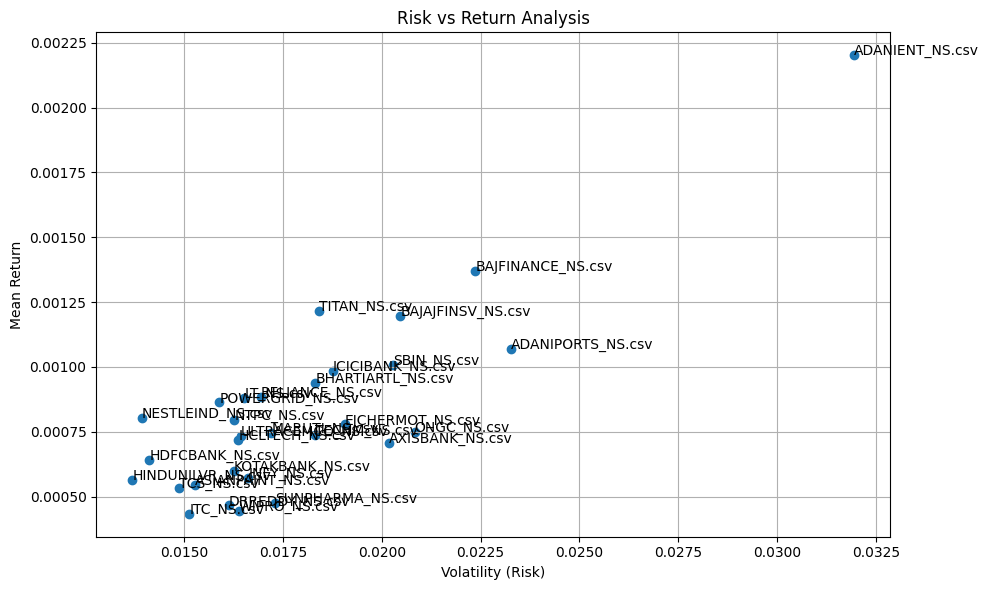

In [6]:
combined = returns_df.join(risk_df)

plt.figure(figsize=(10,6))

plt.scatter(combined["Volatility"], combined["Mean Return"])

for i in combined.index:
    plt.text(combined["Volatility"][i], combined["Mean Return"][i], i)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Mean Return")
plt.title("Risk vs Return Analysis")
save_path = "../../visuals_and_reports/eda_plots/risk_vs_return_plot.png"
plt.savefig(save_path)
plt.tight_layout()
plt.grid(True)
plt.show()

# 07. Key Observations
1. Overall **ADANIENT** i.e. **Adani Enterprises** shows **high return in high risk**.
2. Whereas **BAJFINANCE** i.e. **Bajaj Finance** holds **2nd Positions overall**.